<a href="https://colab.research.google.com/github/fbsilvaRP/ComputerVision-Fundamentals/blob/main/Pr%C3%A1tica01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Início...**

**Definindo as bibliotecas para uso**
---


1.   `import cv2`:visão computacional;

2.   `import matplotlib.pyplot as plt`: Apresentar as imagens em um plano cartesiano.

3.   `from urllib.request import urlopen`: permite obter uma página web;

4. `import numpy`: operar com as imagens matriciais.








In [2]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy

**obtendo uma imagem da web**

---


*   Nome da função: `__obtemImagem__(url, readFlag = cv2.IMREAD_COLOR)`
*   Parâmetros: `url` e `readFlag = cv2.IMREAD_COLOR`:
      1.   "`url`": Endereço da imagem que será inserido;
      2.   "`readFlag = cv2.IMREAD_COLOR`": formato padrão de coloração para a imagem (imagem colorida).


In [3]:
def __obtemImagem__(url, readFlag = cv2.IMREAD_COLOR):
  pacote = urllib.request.urlopen(url)
  pacote = numpy.asarray(bytearray(pacote.read()), dtype = "uint8")
  imagem = cv2.imdecode(pacote, readFlag)
  imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
  return imagem

**Obtendo uma imagem, e exibindo-a:**

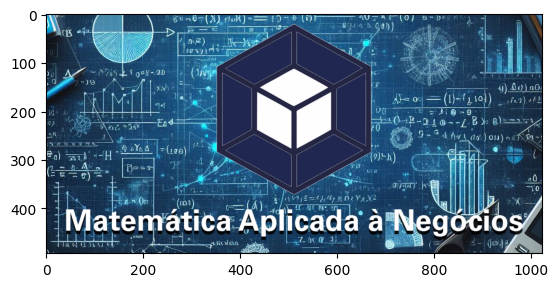

In [4]:
img = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

#Funções para apresentar a imagem: plt.imshow() e plt.show()
plt.imshow(img)
plt.show()

# Obtendo informaçoes da imagem


---



In [5]:
#img.shape retorna (qtd de linhas, qtd de colunas, qtd canais da imagem)
#Ao indicar apenas um item [0], apenas uma informação será obtida

linhas = img.shape[0]
colunas = img.shape[1]
canais = img.shape[2]

l_min = img.min()
l_max = img.max()

print("-=" * 10, "Informações acerca da imagem obtida", "-=" * 10)
print(f"Número de colunas: {colunas}")
print(f"Numero de linhas: {linhas}")
print(f"Número de canais de cores: {canais}")
print(f"Menor intensidade de pixel: {l_min}")
print(f"Maior intensidade de pixel: {l_max}")
print("-=" * 38)



-=-=-=-=-=-=-=-=-=-= Informações acerca da imagem obtida -=-=-=-=-=-=-=-=-=-=
Número de colunas: 1024
Numero de linhas: 493
Número de canais de cores: 3
Menor intensidade de pixel: 0
Maior intensidade de pixel: 255
-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=


**Plotando canais**
---

*  ` janela`: objeto principal que representa a janela ou a página inteira onde os gráficos serão inseridos;

*   `matriz`: Matriz que contém cada um dos subgráficos;

*   `plt.subplots(1,3)`: o primeiro valor (`1`) define o número de linhas, e o segundo (`3`) define o número de colunas.

*   `figsize = (20, 20)`: Define o tamanho da figura. O primeiro valor é a largura, e o segundo é a altura;

`matriz[0].imshow(...)`: transforma a matriz de números em uma imagem visualizável

  * `img[:, :, 0]`:  é definido um intervalo para obter a imagem: `[linhaInicial:linhaFinal, colunaInicial:colunaFinal, canal]`

  * O símbolo : corresponde a utilizar 0:0, isto é, início:fim.
  
  **Deixando de inserir valores, todas as linhas serão coletadas.**

  **Uma imagem colorida apresenta 3 camadas**:
  * 0: Vermelho (Red)
  *  1: Verde (Green)
  *  2: Azul (Blue)

  Ao indicar apenas um canal [:, :, 0] (vermelho, por exemplo), todas as linhas e todas colunas serão coletadas, mas apenas do canal vermelho.

O que cmap = 'gray' realiza?


1.   O python utilizará uma escala de cinza para representar os valores numéricos de intensidade;

2.   Onde a imagem original tinha muito vermelho, o gráfico ficará branco (maior intensidade);

3. cmap = 'gray' transforma os valores numéricos da matriz em tons que vão do preto ao branco






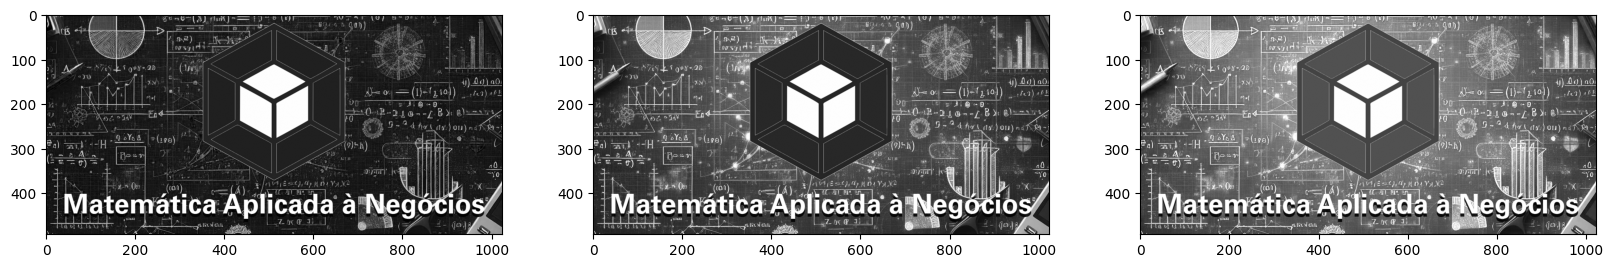

In [6]:
#Criando a estrutura
janela, matriz = plt.subplots(1, 3, figsize = (20, 20))

#Utiliza o primeiro subgráfico [0]
matriz[0].imshow(img[:, :,0], cmap = 'grey')
#utiliza o segundo subgráfico [1]
matriz[1].imshow(img[:, :, 1], cmap = 'grey')
#Utiliza o terceiro subgráfico [2]
matriz [2].imshow(img[:, :, 2], cmap = 'grey')

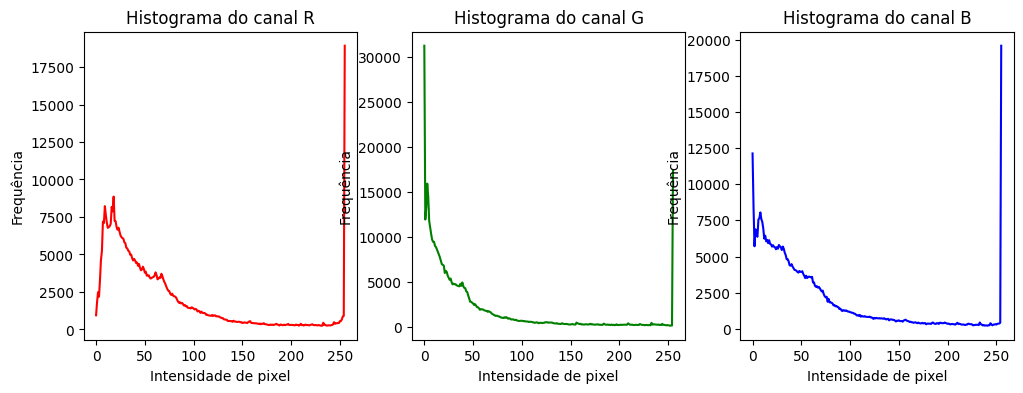

In [10]:
imagem = __obtemImagem__("https://dcm.ffclrp.usp.br/images/bcc.png")

blue, green, red = cv2.split(imagem)

def __histogramaCanal__(canal, cor, nome):
  #Calcula o histograma de um canal e cria um plot pra ele
  hist = cv2.calcHist([canal], [0], None, [256], [0, 256])

  plt.plot(hist, color = cor)
  plt.title(f'Histograma do canal {nome}')
  plt.xlabel(f'Intensidade de pixel')
  plt.ylabel(f'Frequência')

#Plota os histogramas:
plt.figure(figsize = (12, 4))
plt.subplot(1, 3, 1)
__histogramaCanal__(red, 'r', 'R')
plt.subplot(1, 3, 2)
__histogramaCanal__(green, 'g', 'G')
plt.subplot(1, 3, 3)
__histogramaCanal__(blue, 'b', 'B')
plt.show()



**Zerando Canais**

---



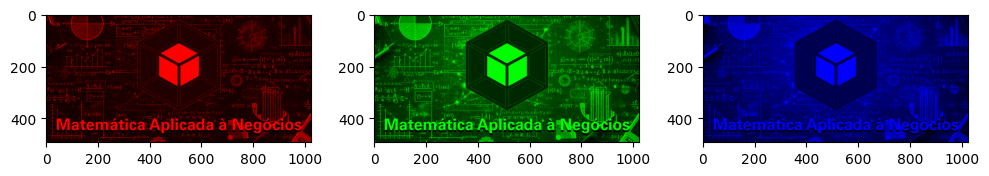

In [13]:
imagem = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

colors = ("r", "g", "b")
plt.figure(figsize = (10, 5))
for i, col in enumerate(colors):
  split_img = numpy.zeros(imagem.shape, dtype = "uint8")
  plt.subplot(1 ,3, i + 1)
  split_img[:, :, i] = img[:, :, i]
  plt.imshow(split_img)

plt.tight_layout()
plt.show()


 **Zerando Pixels específicos em uma imagem**

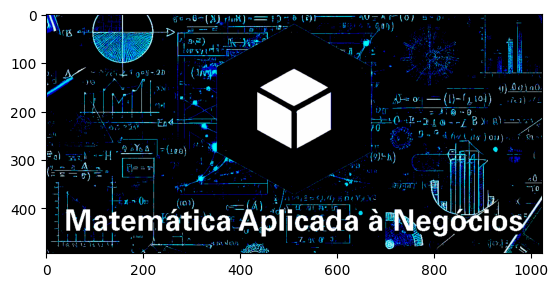

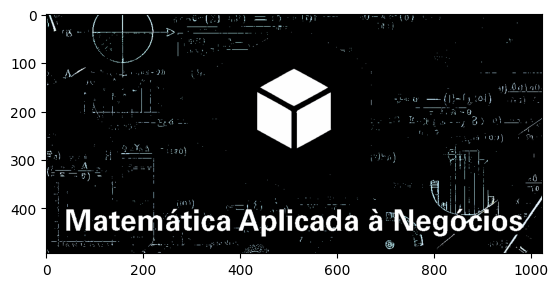

In [16]:
img = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

img1 = img
img1[img1 < 180] = 0
#Zera pixels com intensidade menor que 180
plt.imshow(img1)
plt.show()

#Zerando pixels com intensidade menor que 180 em um canal especifíco
img2 = img
img2[img1[: ,:, 0] < 180] = 0
plt.imshow(img2)
plt.show()

**Imagem negativa**

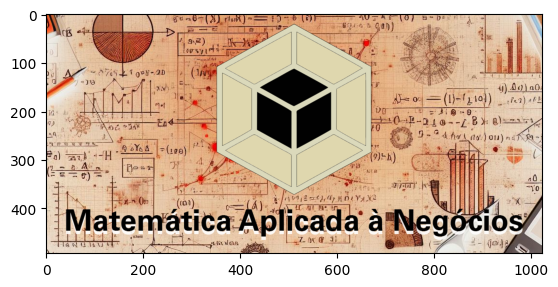

In [17]:
img = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

img2 = 255 - img
plt.imshow(img2)
plt.show()

**Modificando partes da imagem**


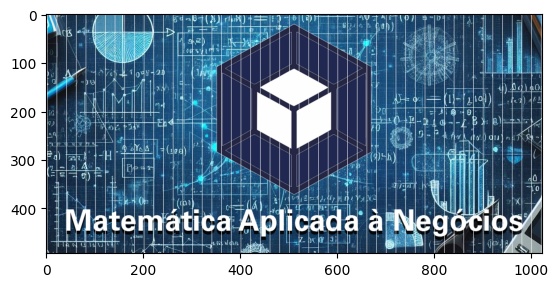

In [18]:
imagem = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

for y in range(0, imagem.shape[0], 20):
  for x in range(0, imagem.shape[1], 20):
    imagem[y:y+20, x+2] = (255,255,255)

plt.imshow(imagem)
plt.show()

**Cortando uma imagem**



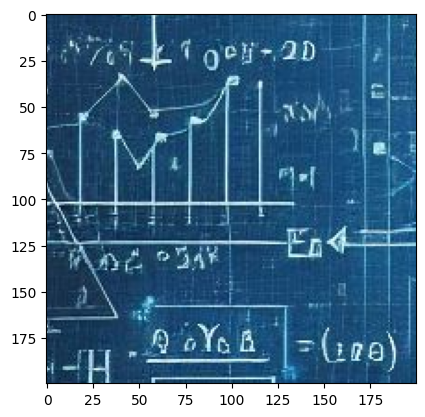

True

In [20]:
imagem = __obtemImagem__("https://dcm.ffclrp.usp.br/images/mat.png")

recorte = imagem[100:300, 100:300]
plt.imshow(recorte)
plt.show()

#Salva a imagem
cv2.imwrite("recorte.png", recorte)
